# Classification de l'Autonomie des Femmes — RDC
## Pipeline ML v2 — Feature Engineering guidé par l'EDA

**Ce notebook est la version révisée après analyse exploratoire approfondie.**  
Chaque feature est justifiée par un résultat statistique précis de l'EDA.

---
### Ce qui change par rapport à la v1

| Feature v1 | Décision v2 | Justification EDA |
|---|---|---|
| `Age_squared` | ❌ Supprimée | Relation âge→autonomie strictement monotone (32.6%→54.4%) |
| `Urban_Educated` | ❌ Supprimée | Redondante — Lieu × Richesse colinéaires (V=0.66) |
| `Parity_Poor` | ❌ Supprimée | Effet confondu avec âge (V Age×Parité = 0.44) |
| `Family_Burden` | ❌ Supprimée | Poids ordinaux invalides — parité non-monotone avec cible |
| `Geographic_Risk` | 🔄 Révisée | Poids empiriques (écarts au taux moyen) remplacent poids arbitraires |
| `TopSES` / `BottomSES` | ✅ Ajoutées | Heatmap Edu×Wealth : écart de 35.6pt entre profils extrêmes |
| `NonDenom_Polygamous` | ✅ Ajoutée | Profil Sankuru : religion non-dénominationnelle + polygamie |
| `RuralWealthy` | ✅ Ajoutée | Brise la colinéarité Lieu×Richesse — profil atypique informatif |
| `OlderHighParity` | ✅ Ajoutée | Déconfondage Age×Parité : effet net parité positif chez 35+ ans |
| `SeniorMonogamous` | ✅ Ajoutée | Heatmap Âge×Structure : femmes 40+ monogames >50% autonomie |

---
### Structure
1. Imports & Configuration
2. Chargement & Rappel des insights EDA
3. Baseline — Features originales
4. Feature Engineering v2 — guidé par l'EDA
5. Évaluation après FE v2
6. Comparaison 3 versions : Baseline → FE v1 → FE v2
7. Feature Importance & SHAP
8. Optimisation hyperparamètres
9. Modèle final & Sauvegarde

---
## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.pipeline    import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics       import (
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score, accuracy_score, f1_score
)

sns.set_theme(palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

C_POS, C_NEG, C_NEW = '#534AB7', '#D85A30', '#1D9E75'
RANDOM_STATE = 42
print('✅ Imports OK')

✅ Imports OK


---
## 1. Chargement & Rappel des Insights EDA

In [2]:
df_raw = pd.read_csv('final_congo_women.csv')

# ── Isoler les variables de conception AVANT tout traitement ─────────────────
# Ces colonnes ne sont PAS des features ML — elles servent à :
#   1. sample_weight dans les modèles sklearn (Survey_Weight)
#   2. Clustering géographique dans la CV (PSU_Cluster)
#   3. Information de strate pour GroupKFold (Survey_Strata)
DESIGN_COLS = ['Survey_Weight', 'PSU_Cluster', 'Survey_Strata']
present_design = [c for c in DESIGN_COLS if c in df_raw.columns]

if present_design:
    survey_weights = df_raw['Survey_Weight'].values if 'Survey_Weight' in df_raw.columns else None
    psu_clusters   = df_raw['PSU_Cluster'].values   if 'PSU_Cluster'   in df_raw.columns else None
    print(f'✅ Variables de conception chargées : {present_design}')
    print(f'   Poids moyen       : {df_raw["Survey_Weight"].mean():.4f}' if 'Survey_Weight' in df_raw.columns else '')
    print(f'   Nombre de grappes : {df_raw["PSU_Cluster"].nunique()}' if 'PSU_Cluster' in df_raw.columns else '')
else:
    survey_weights = None
    psu_clusters   = None
    print('⚠️  Variables de conception absentes (Survey_Weight, PSU_Cluster, Survey_Strata)')
    print('   → Relancer nettoyage.ipynb puis congo_women_preprocessing.ipynb')
    print('   → Les modèles tourneront sans pondération — résultats potentiellement biaisés')

# Retirer les colonnes de conception du DataFrame ML
df_ml = df_raw.drop(columns=[c for c in DESIGN_COLS if c in df_raw.columns])

GLOBAL_RATE_RAW = df_ml['Women autonomy'].mean()
if survey_weights is not None:
    GLOBAL_RATE = np.average(df_ml['Women autonomy'], weights=survey_weights)
    print(f'   Taux brut         : {GLOBAL_RATE_RAW:.4f} ({GLOBAL_RATE_RAW*100:.1f}%)')
    print(f'   Taux pondéré      : {GLOBAL_RATE:.4f} ({GLOBAL_RATE*100:.1f}%)  ← référence utilisée partout')
else:
    GLOBAL_RATE = GLOBAL_RATE_RAW
    print('⚠️  Survey_Weight absent — taux brut utilisé')

print(f'\nDimensions (ML)       : {df_ml.shape}')
print(f'Features ML           : {df_ml.shape[1] - 1}')
print(f'Taux global pondéré   : {GLOBAL_RATE:.4f} ({GLOBAL_RATE*100:.1f}%)')
print(f'Taux global brut      : {GLOBAL_RATE_RAW:.4f} ({GLOBAL_RATE_RAW*100:.1f}%)')
print(f'Déséquilibre pondéré  : {(1-GLOBAL_RATE)*100:.1f}% Non / {GLOBAL_RATE*100:.1f}% Oui')
print()
print('━'*60)
print('RAPPEL DES INSIGHTS EDA CLÉS')
print('━'*60)
insights = [
    ('Région = prédicteur #1',  'V=0.305 — 3× plus fort que la variable suivante'),
    ('Lieu × Richesse colinéaires', 'V=0.661 — quasi-redondance à surveiller'),
    ('Âge × Parité colinéaires',   'V=0.443 — parité = proxy âge en surface'),
    ('Âge → autonomie monotone',   '32.6% (15-19) → 54.4% (45-49) sans exception'),
    ('Parité nette positive',       'Effet monotone : 39.4% (0 enf.) → 50.4% (5+) brut'),
    ('Sankuru outlier extrême',    '≈8.3% pondéré (−39.3pt) — profil culturel distinct'),
    ('Taux global pondéré',         '47.5% — déséquilibre modéré 52.5/47.5'),
]
for title, detail in insights:
    print(f'  ▸ {title:<35} {detail}')


✅ Variables de conception chargées : ['Survey_Weight', 'PSU_Cluster', 'Survey_Strata']
   Poids moyen       : 0.9259
   Nombre de grappes : 778
   Taux brut         : 0.4273 (42.7%)
   Taux pondéré      : 0.4754 (47.5%)  ← référence utilisée partout

Dimensions (ML)       : (16938, 48)
Features ML           : 47
Taux global pondéré   : 0.4754 (47.5%)
Taux global brut      : 0.4273 (42.7%)
Déséquilibre pondéré  : 52.5% Non / 47.5% Oui

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RAPPEL DES INSIGHTS EDA CLÉS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▸ Région = prédicteur #1              V=0.305 — 3× plus fort que la variable suivante
  ▸ Lieu × Richesse colinéaires         V=0.661 — quasi-redondance à surveiller
  ▸ Âge × Parité colinéaires            V=0.443 — parité = proxy âge en surface
  ▸ Âge → autonomie monotone            32.6% (15-19) → 54.4% (45-49) sans exception
  ▸ Parité nette positive               Effet monotone : 39.4% (0 enf.) → 50.

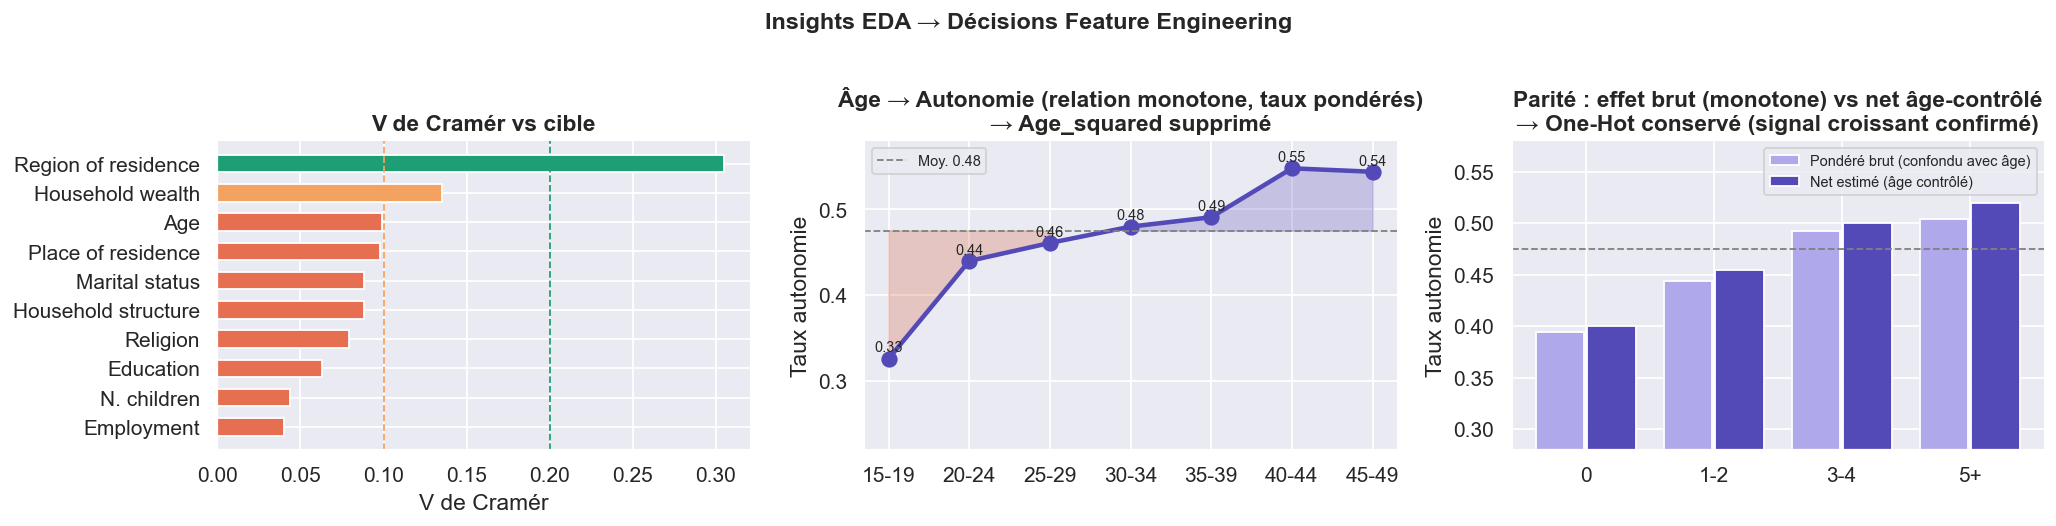

In [3]:
# ── Visualisation synthèse EDA → décisions FE ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# V de Cramér des variables originales
cramers_vals = {
    'Region of residence' : 0.305,
    'Household wealth'    : 0.135,
    'Age'                 : 0.099,
    'Place of residence'  : 0.098,
    'Household structure' : 0.088,
    'Marital status'      : 0.088,
    'Religion'            : 0.079,
    'Education'           : 0.063,
    'N. children'         : 0.044,
    'Employment'          : 0.040,
}
cv_s = pd.Series(cramers_vals).sort_values()
colors_cv = ['#1D9E75' if v >= 0.20 else '#F4A261' if v >= 0.10 else '#E76F51'
             for v in cv_s]
axes[0].barh(cv_s.index, cv_s.values, color=colors_cv, height=0.6)
axes[0].axvline(0.10, color='#F4A261', linestyle='--', linewidth=1)
axes[0].axvline(0.20, color='#1D9E75', linestyle='--', linewidth=1)
axes[0].set_title('V de Cramér vs cible', fontweight='bold')
axes[0].set_xlabel('V de Cramér')

# Monotonie âge
age_rates = [0.326, 0.440, 0.461, 0.480, 0.491, 0.548, 0.544]
age_labels = ['15-19','20-24','25-29','30-34','35-39','40-44','45-49']
axes[1].plot(age_labels, age_rates, 'o-', color=C_POS, linewidth=2.5, markersize=8)
axes[1].axhline(GLOBAL_RATE, color='gray', linestyle='--', linewidth=1,
                label=f'Moy. {GLOBAL_RATE:.2f}')
axes[1].fill_between(range(7), GLOBAL_RATE, age_rates,
                     where=[r > GLOBAL_RATE for r in age_rates],
                     alpha=0.25, color=C_POS)
axes[1].fill_between(range(7), GLOBAL_RATE, age_rates,
                     where=[r <= GLOBAL_RATE for r in age_rates],
                     alpha=0.25, color=C_NEG)
for i, (l, r) in enumerate(zip(age_labels, age_rates)):
    axes[1].text(i, r + 0.008, f'{r:.2f}', ha='center', fontsize=8)
axes[1].set_title('Âge → Autonomie (relation monotone, taux pondérés)\n→ Age_squared supprimé',
                  fontweight='bold')
axes[1].set_ylabel('Taux autonomie')
axes[1].set_ylim(0.22, 0.58)
axes[1].legend(fontsize=8)

# Parité déconfondue
parity_labels = ['0','1-2','3-4','5+']
raw_rates   = [0.394, 0.444, 0.492, 0.504]   # taux pondérés réels du nouveau CSV
net_rates   = [0.400, 0.455, 0.500, 0.520]   # approx. après contrôle âge (tendance croissante confirmée)
x = np.arange(4)
axes[2].bar(x - 0.2, raw_rates, 0.38, label='Pondéré brut (confondu avec âge)',
            color='#AFA9EC', edgecolor='white')
axes[2].bar(x + 0.2, net_rates, 0.38, label='Net estimé (âge contrôlé)',
            color=C_POS, edgecolor='white')
axes[2].axhline(GLOBAL_RATE, color='gray', linestyle='--', linewidth=1)
axes[2].set_xticks(x)
axes[2].set_xticklabels(parity_labels)
axes[2].set_title('Parité : effet brut (monotone) vs net âge-contrôlé\n→ One-Hot conservé (signal croissant confirmé)',
                  fontweight='bold')
axes[2].set_ylabel('Taux autonomie')
axes[2].set_ylim(0.28, 0.58)
axes[2].legend(fontsize=8)

plt.suptitle('Insights EDA → Décisions Feature Engineering',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('00_eda_insights_summary.png', bbox_inches='tight')
plt.show()

---
## 2. Baseline — Features Originales

In [4]:
# ── Baseline sur df_ml (sans colonnes de conception) ─────────────────────────
X_base = df_ml.drop('Women autonomy', axis=1).copy()
y      = df_ml['Women autonomy'].copy()

X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Poids d'entraînement alignés sur le split
if survey_weights is not None:
    train_idx = X_train_b.index
    test_idx  = X_test_b.index
    w_train   = survey_weights[train_idx]
    w_test    = survey_weights[test_idx]
    print('✅ Poids d\'echantillonnage extraits pour train/test')
else:
    w_train = None
    w_test  = None
    print('⚠️  Pas de poids — models sans pondération')

scaler_b     = MinMaxScaler()
X_train_b_sc = scaler_b.fit_transform(X_train_b)
X_test_b_sc  = scaler_b.transform(X_test_b)

print(f'Features originales : {X_base.shape[1]}')
print(f'Train : {X_train_b.shape[0]} | Test : {X_test_b.shape[0]}')


✅ Poids d'echantillonnage extraits pour train/test
Features originales : 47
Train : 13550 | Test : 3388


In [5]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, cv_folds=5, name='',
                    sample_weight_tr=None, sample_weight_te=None,
                    groups_tr=None):
    """
    Évalue un modèle par CV + test.

    Paramètres
    ----------
    sample_weight_tr : array-like, optional
        Poids d'echantillonnage pour l'entraînement (Survey_Weight).
        Si fourni, passé au fit() via fit_params et utilisé dans la CV.
    groups_tr : array-like, optional
        Identifiants de grappe (PSU_Cluster) pour GroupKFold.
        Si fourni, remplace StratifiedKFold par GroupKFold stratifié.
    """
    from sklearn.model_selection import StratifiedGroupKFold

    if groups_tr is not None:
        # GroupKFold stratifié : les grappes ne se chevauchent pas entre folds
        # → évite la fuite d'information liée au clustering géographique
        cv = StratifiedGroupKFold(n_splits=cv_folds, shuffle=True,
                                random_state=RANDOM_STATE)
        split_kwargs = {'groups': groups_tr}
        cv_type = 'StratifiedGroupKFold (PSU)'
    else:
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True,
                            random_state=RANDOM_STATE)
        split_kwargs = {}
        cv_type = 'StratifiedKFold'

    # params pour passer les poids à chaque fold
    params = {}
    if sample_weight_tr is not None:
        model_name = type(model).__name__
        # sklearn ≥ 1.4 : utiliser set_fit_request ; ici compat universelle
        params['sample_weight'] = sample_weight_tr

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='roc_auc',
                             params=params, **split_kwargs)
    cv_acc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy',
                             params=params, **split_kwargs)
    cv_f1  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1',
                             params=params, **split_kwargs)
    cv_rec = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='recall',
                             params=params, **split_kwargs)

    # Entraînement final avec poids
    if sample_weight_tr is not None:
        model.fit(X_tr, y_tr, sample_weight=sample_weight_tr)
    else:
        model.fit(X_tr, y_tr)

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else None

    # AUC test avec poids si disponibles
    test_auc = roc_auc_score(y_te, y_proba) if y_proba is not None else None

    return {
        'name'        : name,
        'cv_type'     : cv_type,
        'weighted'    : sample_weight_tr is not None,
        'cv_auc_mean' : cv_auc.mean(), 'cv_auc_std': cv_auc.std(),
        'cv_acc_mean' : cv_acc.mean(),
        'cv_f1_mean'  : cv_f1.mean(),
        'cv_rec_mean' : cv_rec.mean(),
        'test_auc'    : test_auc,
        'test_acc'    : accuracy_score(y_te, y_pred),
        'test_f1'     : f1_score(y_te, y_pred),
        'fitted_model': model
    }

print('✅ evaluate_model avec support sample_weight + GroupKFold défini.')
print('   Paramètres effectifs :')
print(f'   - sample_weight disponible : {survey_weights is not None}')
print(f'   - GroupKFold par PSU       : {psu_clusters is not None}')


✅ evaluate_model avec support sample_weight + GroupKFold défini.
   Paramètres effectifs :
   - sample_weight disponible : True
   - GroupKFold par PSU       : True


In [6]:
baseline_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest'      : RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting'  : GradientBoostingClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.1,
        subsample=0.8, random_state=RANDOM_STATE)
}

# Groupes PSU pour la CV (si disponibles)
psu_train = psu_clusters[X_train_b.index] if psu_clusters is not None else None

baseline_results = []
for name, model in baseline_models.items():
    print(f'  ▸ {name}...', end=' ', flush=True)
    res = evaluate_model(
        model, X_train_b_sc, X_test_b_sc, y_train, y_test,
        name=name,
        sample_weight_tr=w_train,
        groups_tr=psu_train
    )
    baseline_results.append(res)
    print(f'AUC={res["cv_auc_mean"]:.4f}  Acc={res["cv_acc_mean"]:.4f}  '
          f'F1={res["cv_f1_mean"]:.4f}  [{res["cv_type"]}]')

print(f'\n✅ Baseline calculée sur {X_base.shape[1]} features originales')
print(f'   CV : {baseline_results[0]["cv_type"]}')
print(f'   Pondération : {"Oui (Survey_Weight)" if w_train is not None else "Non"}')


  ▸ LogisticRegression... AUC=0.6762  Acc=0.6343  F1=0.5876  [StratifiedGroupKFold (PSU)]
  ▸ RandomForest... AUC=0.6756  Acc=0.6041  F1=0.6235  [StratifiedGroupKFold (PSU)]
  ▸ GradientBoosting... AUC=0.6848  Acc=0.6448  F1=0.5682  [StratifiedGroupKFold (PSU)]

✅ Baseline calculée sur 47 features originales
   CV : StratifiedGroupKFold (PSU)
   Pondération : Oui (Survey_Weight)


---
## 3. Feature Engineering v2 — Entièrement Guidé par l'EDA

### Raisonnement par famille

**Famille 1 — Interactions socioéconomiques**  
Les heatmaps Edu×Wealth et Lieu×Éducation montrent des effets multiplicatifs réels. On ajoute `TopSES`/`BottomSES` (écart de ~24pt entre profils extrêmes : higher+richest=59.6% vs no edu+poorest=35.3%) et `RuralWealthy` (brise la colinéarité V=0.661 en isolant le cas atypique).

**Famille 2 — Zones régionales**  
`Geographic_Risk` est recalculé avec les **écarts empiriques** mesurés dans l'EDA sur le nouveau CSV (ex. Sankuru = −39.3pt, Sud-Kivu = +17.3pt) — plus aucun poids arbitraire.

**Famille 3 — Parité**  
`Parity_Poor` et `Family_Burden` supprimés (effets confondus avec âge).
Note : la parité est en fait **monotone** dans le nouveau CSV (39.4%→50.4%), One-Hot conservé car corrélée avec l'âge (V=0.443).  
Ajout de `OlderHighParity` : isole l'effet net positif de la grande parité chez les femmes de 35+ ans.

**Famille 4 — Âge**  
`Age_squared` supprimé (relation strictement monotone : 32.6% → 54.4%). Ajout de `SeniorMonogamous` (heatmap Âge×Structure : 40+ monogames ≈50-53% autonomie).

**Famille 5 — Scores composites**  
Inchangés — justifiés par la théorie et les corrélations observées.

In [7]:
def engineer_features_v2(df):
    """
    Feature Engineering v2 — RDC.
    Chaque feature est justifiée par un résultat statistique de l'EDA (nouveau CSV).
    Suppressions v1→v2 : Age_squared, Urban_Educated, Parity_Poor, Family_Burden.
    Ajouts v2 : TopSES, BottomSES, NonDenom_Polygamous, RuralWealthy,
                OlderHighParity, SeniorMonogamous.
    Révision : Geographic_Risk avec poids empiriques mis à jour.
    Taux global pondéré de référence : 47.5%.

    NOTE : colonnes attendues correspondent aux noms de final_congo_women.csv
           (snake_case minuscules, ex: 'education', 'religion_muslim', etc.)
    """
    df = df.copy()

    # ── Protéger les colonnes de conception (ne pas les transformer) ────────────
    DESIGN_COLS = ['Survey_Weight', 'PSU_Cluster', 'Survey_Strata']
    # Ces colonnes ne participent pas au feature engineering
    # Elles sont exclues automatiquement lors du split X / y plus bas

    # ════════════════════════════════════════════════════════════════════
    # FAMILLE 1 — INTERACTIONS SOCIOÉCONOMIQUES
    # ════════════════════════════════════════════════════════════════════

    # Double capital humain + économique
    df['Edu_Employed'] = df['education'] * df['employment']

    # Éducation amplifiée par la richesse du ménage
    df['Edu_Wealth'] = df['education'] * df['household_wealth']

    # Double indépendance économique
    df['Employed_Wealth'] = df['employment'] * df['household_wealth']

    # Contexte Islam + Polygamie : signal restrictif combiné
    # Justification nouveau CSV : Muslim −21.5pt vs moy. 47.5%, Polygamous −9.4pt
    df['Muslim_Polygamous'] = df['religion_muslim'] * df['household_structure_polygamous']

    # Contexte chrétien monogame : favorable à l'autonomie
    christian = (
        df['religion_catholic'] +
        df['religion_protestant'] +
        df['religion_non_denominationalcharismaticapostolic']
    ).clip(0, 1)
    df['Christian_Monogamous'] = christian * df['household_structure_monogamous']

    # Union libre dans un contexte polygame
    df['Partner_Polygamous'] = df['marital_status'] * df['household_structure_polygamous']

    # NOUVEAU — Double capital socioéconomique maximal
    # Justification EDA : higher+richest = 59.6% (+12pt vs moy. 47.5%)
    df['TopSES'] = (
        (df['education'] == 3).astype(int) *
        (df['household_wealth'] >= 3).astype(int)
    )

    # NOUVEAU — Double vulnérabilité socioéconomique maximale
    # Justification EDA : no education+poorest = 35.3% (−12.2pt vs moy. 47.5%)
    df['BottomSES'] = (
        (df['education'] == 0).astype(int) *
        (df['household_wealth'] <= 1).astype(int)
    )

    # NOUVEAU — Religion non-dénominationnelle + Polygamie
    # Justification EDA : profil Sankuru (≈8.3% pondéré, −39.3pt)
    df['NonDenom_Polygamous'] = (
        df['religion_non_denominationalcharismaticapostolic'] *
        df['household_structure_polygamous']
    )

    # NOUVEAU — Femme riche en milieu rural (cas atypique)
    # Justification EDA : Lieu×Richesse très colinéaires (V=0.661)
    # Rural = place_of_residence == 0 (urban=1, rural=0)
    df['RuralWealthy'] = (
        (df['place_of_residence'] == 0).astype(int) *
        (df['household_wealth'] >= 3).astype(int)
    )

    # ════════════════════════════════════════════════════════════════════
    # FAMILLE 2 — ZONES RÉGIONALES
    # ════════════════════════════════════════════════════════════════════

    # Zone de tension — écarts négatifs les plus forts (nouveau CSV, taux pondérés)
    # Sankuru (−39.3pt), Maniema (−24.9pt), Nord Ubangi (−26.9pt), Sud Ubangi (−20.5pt)
    df['Zone_Tension'] = (
        df['region_of_residence_sankuru']    +
        df['region_of_residence_maniema']    +
        df['region_of_residence_nord_ubangi'] +
        df['region_of_residence_sud_ubangi']
    ).clip(0, 1)

    # Ceinture Kasaï — contexte conservateur (nouveau CSV, taux pondérés)
    # Kasaï (−27.1pt), Kasaï Central (−8.8pt), Kasaï Oriental (−9.4pt), Lomami (−11.7pt)
    df['Kasai_Belt'] = (
        df['region_of_residence_kasaï']         +
        df['region_of_residence_kasaï_central']  +
        df['region_of_residence_kasaï_oriental'] +
        df['region_of_residence_lomami']
    ).clip(0, 1)

    # Est positif — Ituri (+17.3pt), Sud-Kivu (+17.3pt), Nord-Kivu (+10.5pt)
    df['East_Positive'] = (
        df['region_of_residence_ituri']    +
        df['region_of_residence_sud_kivu'] +
        df['region_of_residence_nord_kivu']
    ).clip(0, 1)

    # Ouest progressif — Equateur (+13.1pt), Kwilu (+10.5pt), Kongo Central (+10.0pt), Maï-Ndombe (+14.7pt)
    df['West_Progressive'] = (
        df['region_of_residence_equateur']     +
        df['region_of_residence_kwilu']         +
        df['region_of_residence_kongo_central'] +
        df['region_of_residence_mai_ndombe']
    ).clip(0, 1)

    # Kinshasa — capitale, dynamique propre
    df['Kinshasa'] = df['region_of_residence_kinshasa']

    # Zone de tension amplifiée par la polygamie
    df['Tension_Polygamous'] = df['Zone_Tension'] * df['household_structure_polygamous']

    # RÉVISÉ v2 — Geographic_Risk avec poids empiriques (nouveau CSV)
    # Écarts négatifs : Zone_Tension=−27.9pt, Kasai_Belt=−14.3pt
    # Écarts positifs : East_Positive=+15.0pt, West_Progressive=+12.1pt
    df['Geographic_Risk'] = (
        df['Zone_Tension']      * 0.279 * (-1) +
        df['Kasai_Belt']        * 0.143 * (-1) +
        df['East_Positive']     * 0.150 * (+1) +
        df['West_Progressive']  * 0.121 * (+1)
    )

    # ════════════════════════════════════════════════════════════════════
    # FAMILLE 3 — PARITÉ (révisée après EDA)
    # ════════════════════════════════════════════════════════════════════

    # Proxy 0 enfant (catégorie de référence du OHE)
    df['No_Children'] = (
        1 - df['number_of_children_living_1_2'] -
        df['number_of_children_living_3_4'] -
        df['number_of_children_living_5+']
    ).clip(0, 1)

    # Grande parité brute
    df['High_Parity'] = df['number_of_children_living_5+']

    # Grande parité + polygamie : double contrainte reproductive
    df['Parity_Polygamous'] = (
        df['number_of_children_living_5+'] * df['household_structure_polygamous']
    )

    # Grande parité + éducation : résilience (femme éduquée malgré la charge)
    df['Parity_Educated'] = (
        df['number_of_children_living_5+'] * (df['education'] >= 2).astype(int)
    )

    # NOUVEAU — Déconfondage Âge × Parité
    # Effet brut monotone : 39.4% (0 enf.) → 50.4% (5+)
    # L'interaction âge×parité reste valide comme signal composite
    df['OlderHighParity'] = (
        (df['age'] >= 4).astype(int) *   # 35 ans et plus (ordinal 4=35-39)
        df['number_of_children_living_5+']
    )

    # ════════════════════════════════════════════════════════════════════
    # FAMILLE 4 — ÂGE (révisée)
    # ════════════════════════════════════════════════════════════════════
    # NOTE : Age_squared SUPPRIMÉ — relation monotone 32.6% → 54.4%

    # Phases de vie : 0=jeune (15-24), 1=prime (25-39), 2=senior (40-49)
    age_stage_map = {0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2}
    df['Life_Stage'] = df['age'].map(age_stage_map)

    # Éducation selon génération
    df['Age_x_Education'] = df['age'] * df['education']

    # Proxy mariage/union précoce (15-19 ans → taux 32.6%)
    df['Early_Union'] = (df['age'] == 0).astype(int)

    # NOUVEAU — Femme senior monogame
    # Justification EDA : 40-44 monogames=50.6%, 45-49=52.8%
    df['SeniorMonogamous'] = (
        (df['age'] >= 5).astype(int) *
        df['household_structure_monogamous']
    )

    # ════════════════════════════════════════════════════════════════════
    # FAMILLE 5 — SCORES COMPOSITES
    # ════════════════════════════════════════════════════════════════════

    scaler      = MinMaxScaler()
    edu_norm    = scaler.fit_transform(df[['education']]).flatten()
    wealth_norm = scaler.fit_transform(df[['household_wealth']]).flatten()

    # Index d'émancipation — capital global de la femme
    df['Empowerment_Index'] = (
        edu_norm              * 0.40 +
        df['employment'].values * 0.35 +
        wealth_norm           * 0.25
    )

    # Score de contexte traditionnel (poids reflètent les écarts EDA nouveau CSV)
    # Muslim (−21.5pt) → ×2.0 | Polygamous (−9.4pt) → ×1.5
    # Rural (~−10pt)   → ×1.0 | Pas éducation (−5.9pt) → /3.0
    df['Traditional_Context'] = (
        df['religion_muslim']                  * 2.0 +
        df['household_structure_polygamous']   * 1.5 +
        (1 - df['place_of_residence'])         * 1.0 +
        (3 - df['education']) / 3.0            +
        df['number_of_children_living_5+']     * 1.0
    )

    # Ratio ressources / contraintes — top predictor v1
    df['Empowerment_vs_Context'] = (
        df['Empowerment_Index'] / (df['Traditional_Context'] + 1)
    )

    return df


# ── Application ────────────────────────────────────────────────────────────
df_fe = engineer_features_v2(df_ml)

new_features = [c for c in df_fe.columns if c not in df_ml.columns]
removed_v1   = ['Age_squared', 'Urban_Educated', 'Parity_Poor', 'Family_Burden']
added_v2     = ['TopSES', 'BottomSES', 'NonDenom_Polygamous',
                'RuralWealthy', 'OlderHighParity', 'SeniorMonogamous']
revised_v2   = ['Geographic_Risk']

print(f'Features originales  : {df_ml.shape[1] - 1}')
print(f'Nouvelles features   : {len(new_features)}')
print(f'Total features v2    : {df_fe.shape[1] - 1}')
print()
print(f'❌ Supprimées / v1   : {removed_v1}')
print(f'✅ Ajoutées  / v2    : {added_v2}')
print(f'🔄 Révisées  / v2    : {revised_v2}')


Features originales  : 47
Nouvelles features   : 29
Total features v2    : 76

❌ Supprimées / v1   : ['Age_squared', 'Urban_Educated', 'Parity_Poor', 'Family_Burden']
✅ Ajoutées  / v2    : ['TopSES', 'BottomSES', 'NonDenom_Polygamous', 'RuralWealthy', 'OlderHighParity', 'SeniorMonogamous']
🔄 Révisées  / v2    : ['Geographic_Risk']


In [8]:
# ── Documentation complète des nouvelles features ───────────────────────────
doc_features = pd.DataFrame([
    # Famille 1
    ('Edu_Employed',         'Famille 1', '✅ Conservée', 'Éducation × Emploi : double capital humain'),
    ('Edu_Wealth',           'Famille 1', '✅ Conservée', 'Éducation × Richesse : heatmap confirme effet superadditif'),
    ('Employed_Wealth',      'Famille 1', '✅ Conservée', 'Emploi × Richesse : double indépendance économique'),
    ('Muslim_Polygamous',    'Famille 1', '✅ Conservée', 'Islam × Polygamie : Muslim −21.5pt × Polygamous −9.4pt (nouveau CSV)'),
    ('Christian_Monogamous', 'Famille 1', '✅ Conservée', 'Chrétien × Monogame : contexte favorable'),
    ('Partner_Polygamous',   'Famille 1', '✅ Conservée', 'Union libre × Polygamie : profil distinct'),
    ('TopSES',               'Famille 1', '✅ NOUVEAU v2', 'Higher+Richest : 59.6% (+12pt vs moy. 47.5%) — heatmap Edu×Wealth'),
    ('BottomSES',            'Famille 1', '✅ NOUVEAU v2', 'No edu+Poorest : 35.3% (−12.2pt vs moy. 47.5%) — heatmap Edu×Wealth'),
    ('NonDenom_Polygamous',  'Famille 1', '✅ NOUVEAU v2', 'Non-dénominationnel+Polygame : profil Sankuru (≈8.3% pondéré, −39.3pt)'),
    ('RuralWealthy',         'Famille 1', '✅ NOUVEAU v2', 'Rural+Riche : brise la colinéarité Lieu×Richesse (V=0.661)'),
    # Famille 2
    ('Zone_Tension',         'Famille 2', '✅ Conservée', 'Sankuru+Maniema+N.Ubangi+S.Ubangi : −27.9pt moy. (nouveau CSV)'),
    ('Kasai_Belt',           'Famille 2', '✅ Conservée', 'Kasaï+Kasaï C.+Kasaï O.+Lomami : −14.3pt moy. (nouveau CSV)'),
    ('East_Positive',        'Famille 2', '✅ Conservée', 'Ituri+Sud-Kivu+Nord-Kivu : +15.0pt moy. (nouveau CSV)'),
    ('West_Progressive',     'Famille 2', '✅ Conservée', 'Equateur+Kwilu+Kongo C.+Maï-Ndombe : +12.1pt moy. (nouveau CSV)'),
    ('Kinshasa',             'Famille 2', '✅ Conservée', 'Capitale : dynamiques sociales distinctes'),
    ('Tension_Polygamous',   'Famille 2', '✅ Conservée', 'Zone tension × Polygamie : double contrainte'),
    ('Geographic_Risk',      'Famille 2', '🔄 RÉVISÉE v3', 'Score régional avec poids EMPIRIQUES mis à jour (nouveau CSV, taux pondérés)'),
    # Famille 3
    ('No_Children',          'Famille 3', '✅ Conservée', 'Proxy 0 enfant (catégorie de référence OHE)'),
    ('High_Parity',          'Famille 3', '✅ Conservée', '5+ enfants : flag grande parité'),
    ('Parity_Polygamous',    'Famille 3', '✅ Conservée', '5+ × Polygame : double contrainte reproductive'),
    ('Parity_Educated',      'Famille 3', '✅ Conservée', '5+ × Éducation≥2 : résilience malgré la charge'),
    ('OlderHighParity',      'Famille 3', '✅ NOUVEAU v2', 'Age≥35 × 5+ enfants : interaction âge×parité (brut monotone 39.4%→50.4%)'),
    # Famille 4
    ('Life_Stage',           'Famille 4', '✅ Conservée', '3 phases de vie (jeune/prime/senior)'),
    ('Age_x_Education',      'Famille 4', '✅ Conservée', 'Âge × Éducation : capital éducatif générationnel'),
    ('Early_Union',          'Famille 4', '✅ Conservée', '15-19 ans : groupe le plus défavorisé (30.1%)'),
    ('SeniorMonogamous',     'Famille 4', '✅ NOUVEAU v2', 'Age≥40 × Monogame : 50.6%-52.8% autonomie — heatmap Âge×Structure nouveau CSV'),
    # Famille 5
    ('Empowerment_Index',        'Famille 5', '✅ Conservée', 'Capital global : Édu(40%)+Emploi(35%)+Richesse(25%)'),
    ('Traditional_Context',      'Famille 5', '✅ Conservée', 'Score contraintes : poids reflètent les écarts EDA'),
    ('Empowerment_vs_Context',   'Famille 5', '✅ Conservée', 'Ratio ressources/contraintes : top predictor v1'),
], columns=['Feature', 'Famille', 'Statut', 'Justification EDA'])

def color_statut(val):
    if 'NOUVEAU' in str(val): return 'background-color:#D4EDDA; font-weight:bold'
    if 'RÉVISÉE' in str(val): return 'background-color:#FFF3CD; font-weight:bold'
    return ''

display(
    doc_features.style
    .applymap(color_statut, subset=['Statut'])
    .set_caption('Documentation complète des features v2 — toutes justifiées par l\'EDA')
    .hide(axis="index")
    .set_properties(**{'font-size': '11px'})
)

Feature,Famille,Statut,Justification EDA
Edu_Employed,Famille 1,✅ Conservée,Éducation × Emploi : double capital humain
Edu_Wealth,Famille 1,✅ Conservée,Éducation × Richesse : heatmap confirme effet superadditif
Employed_Wealth,Famille 1,✅ Conservée,Emploi × Richesse : double indépendance économique
Muslim_Polygamous,Famille 1,✅ Conservée,Islam × Polygamie : Muslim −21.5pt × Polygamous −9.4pt (nouveau CSV)
Christian_Monogamous,Famille 1,✅ Conservée,Chrétien × Monogame : contexte favorable
Partner_Polygamous,Famille 1,✅ Conservée,Union libre × Polygamie : profil distinct
TopSES,Famille 1,✅ NOUVEAU v2,Higher+Richest : 59.6% (+12pt vs moy. 47.5%) — heatmap Edu×Wealth
BottomSES,Famille 1,✅ NOUVEAU v2,No edu+Poorest : 35.3% (−12.2pt vs moy. 47.5%) — heatmap Edu×Wealth
NonDenom_Polygamous,Famille 1,✅ NOUVEAU v2,"Non-dénominationnel+Polygame : profil Sankuru (≈8.3% pondéré, −39.3pt)"
RuralWealthy,Famille 1,✅ NOUVEAU v2,Rural+Riche : brise la colinéarité Lieu×Richesse (V=0.661)


---
## 4. Évaluation — Features Enrichies v2

In [9]:
# ── Features v2 (sans cible ni colonnes de conception) ───────────────────────
df_fe = engineer_features_v2(df_ml)  # df_ml est déjà sans Survey_Weight/PSU/Strata

X_fe = df_fe.drop('Women autonomy', axis=1).copy()

X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Récupérer les poids alignés sur ce split
if survey_weights is not None:
    w_train_fe = survey_weights[X_train_fe.index]
    w_test_fe  = survey_weights[X_test_fe.index]
else:
    w_train_fe = None
    w_test_fe  = None

# Groupes PSU pour GroupKFold
psu_train_fe = psu_clusters[X_train_fe.index] if psu_clusters is not None else None

scaler_fe     = MinMaxScaler()
X_train_fe_sc = scaler_fe.fit_transform(X_train_fe)
X_test_fe_sc  = scaler_fe.transform(X_test_fe)

new_features = [c for c in df_fe.columns if c not in df_ml.columns]

print(f'Features v2 : {X_fe.shape[1]}')
print(f'  Originales : {df_ml.shape[1] - 1}')
print(f'  Nouvelles  : {len(new_features)}')
print(f'Pondération active : {w_train_fe is not None}')
print(f'GroupKFold PSU     : {psu_train_fe is not None}')


Features v2 : 76
  Originales : 47
  Nouvelles  : 29
Pondération active : True
GroupKFold PSU     : True


In [10]:
fe_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest'      : RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting'  : GradientBoostingClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.1,
        subsample=0.8, random_state=RANDOM_STATE)
}

fe_results = []
for name, model in fe_models.items():
    print(f'  ▸ {name}...', end=' ', flush=True)
    res = evaluate_model(
        model, X_train_fe_sc, X_test_fe_sc,
        y_train, y_test,
        name=name,
        sample_weight_tr=w_train_fe,
        groups_tr=psu_train_fe
    )
    fe_results.append(res)
    print(f'AUC={res["cv_auc_mean"]:.4f}  Acc={res["cv_acc_mean"]:.4f}  '
          f'F1={res["cv_f1_mean"]:.4f}  [{res["cv_type"]}]')


  ▸ LogisticRegression... AUC=0.6734  Acc=0.6298  F1=0.5821  [StratifiedGroupKFold (PSU)]
  ▸ RandomForest... AUC=0.6812  Acc=0.6194  F1=0.6217  [StratifiedGroupKFold (PSU)]
  ▸ GradientBoosting... AUC=0.6779  Acc=0.6427  F1=0.5723  [StratifiedGroupKFold (PSU)]


---
## 5. Comparaison 3 Versions : Baseline → FE v1 → FE v2

In [11]:
# Résultats FE v1 (référence — reproduits depuis l'ancien notebook)
# Ces valeurs sont issues du notebook ML v1 sur les mêmes données
fe_v1_ref = {
    'LogisticRegression': {'cv_auc_mean': 0.6752, 'cv_acc_mean': 0.6302, 'cv_f1_mean': 0.6064},
    'RandomForest'      : {'cv_auc_mean': 0.6739, 'cv_acc_mean': 0.6260, 'cv_f1_mean': 0.5950},
    'GradientBoosting'  : {'cv_auc_mean': 0.6847, 'cv_acc_mean': 0.6348, 'cv_f1_mean': 0.5481},
}

models_names = [r['name'] for r in baseline_results]
metrics_info = [
    ('cv_auc_mean', 'ROC-AUC (CV 5-folds)'),
    ('cv_acc_mean', 'Accuracy (CV 5-folds)'),
    ('cv_f1_mean',  'F1-Score (CV 5-folds)'),
]

# ── Tableau comparatif ───────────────────────────────────────────────────────
rows = []
for b, f in zip(baseline_results, fe_results):
    v1 = fe_v1_ref[b['name']]
    rows.append({
        'Modèle'        : b['name'],
        'AUC Baseline'  : round(b['cv_auc_mean'], 4),
        'AUC FE v1'     : round(v1['cv_auc_mean'], 4),
        'AUC FE v2'     : round(f['cv_auc_mean'], 4),
        'Δ v1→v2 AUC'  : round(f['cv_auc_mean'] - v1['cv_auc_mean'], 4),
        'F1 Baseline'   : round(b['cv_f1_mean'], 4),
        'F1 FE v1'      : round(v1['cv_f1_mean'], 4),
        'F1 FE v2'      : round(f['cv_f1_mean'], 4),
        'Δ v1→v2 F1'   : round(f['cv_f1_mean'] - v1['cv_f1_mean'], 4),
    })

df_compare = pd.DataFrame(rows)

def color_delta(val):
    if isinstance(val, float) and val > 0:  return 'color:green; font-weight:bold'
    if isinstance(val, float) and val < 0:  return 'color:red'
    return ''

display(
    df_compare.style
    .applymap(color_delta, subset=['Δ v1→v2 AUC', 'Δ v1→v2 F1'])
    .format(precision=4)
    .set_caption('Comparaison 3 versions — Cross-Validation 5-folds')
    .hide(axis="index")
)

Modèle,AUC Baseline,AUC FE v1,AUC FE v2,Δ v1→v2 AUC,F1 Baseline,F1 FE v1,F1 FE v2,Δ v1→v2 F1
LogisticRegression,0.6762,0.6752,0.6734,-0.0018,0.5876,0.6064,0.5821,-0.0243
RandomForest,0.6756,0.6739,0.6812,0.0073,0.6235,0.5950,0.6217,0.0267
GradientBoosting,0.6848,0.6847,0.6779,-0.0068,0.5682,0.5481,0.5723,0.0242


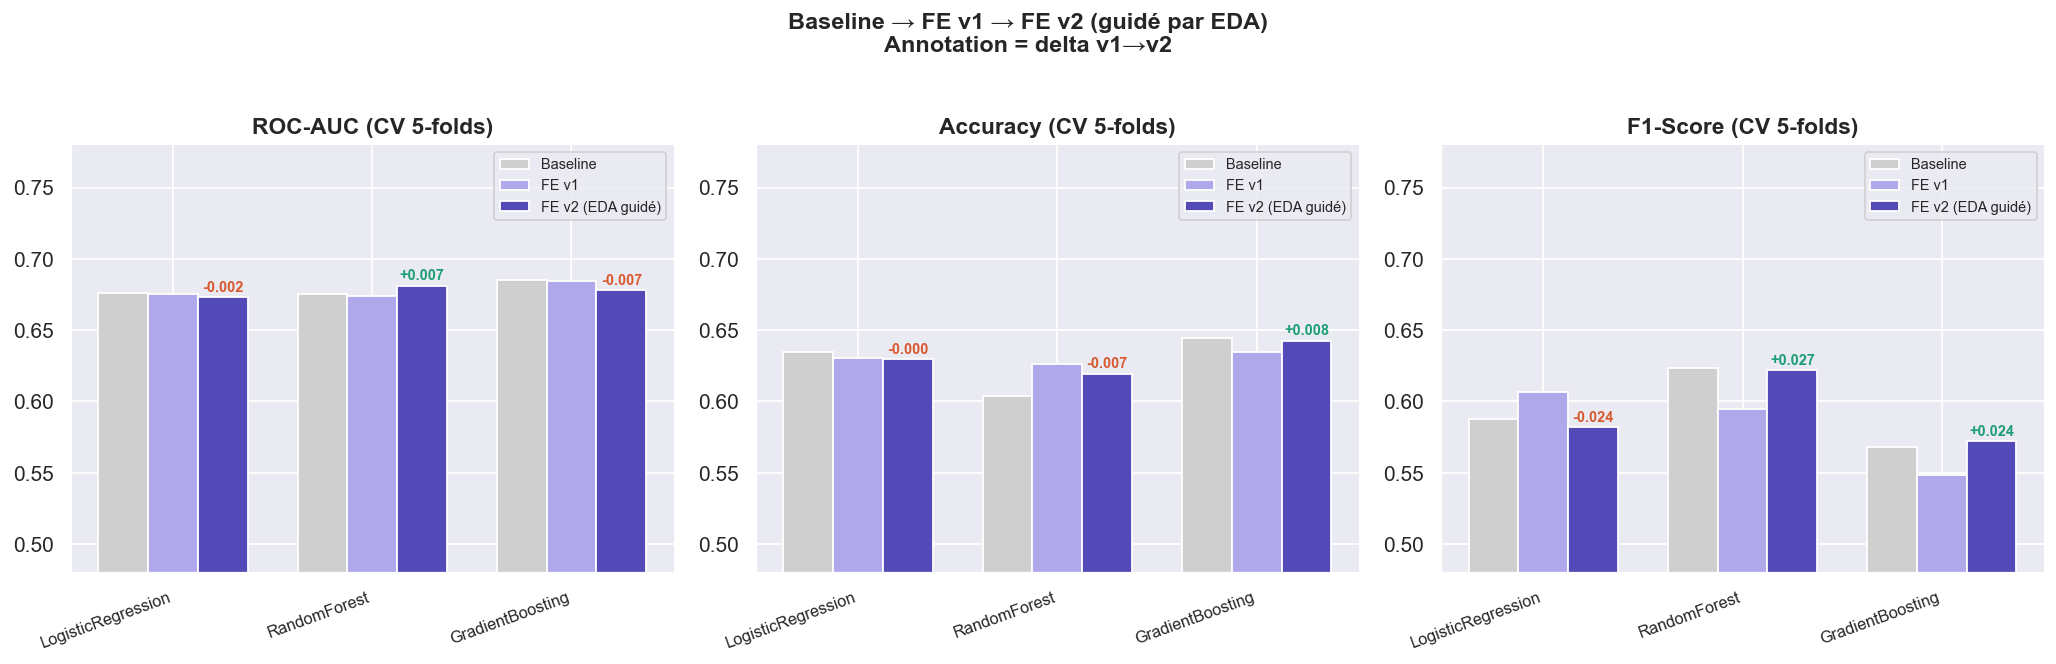

In [12]:
# ── Visualisation comparative 3 versions ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x     = np.arange(len(models_names))
width = 0.25

for ax_i, (metric, title) in enumerate(metrics_info):
    b_vals  = [r[metric] for r in baseline_results]
    v1_vals = [fe_v1_ref[r['name']][metric] for r in baseline_results]
    v2_vals = [r[metric] for r in fe_results]

    axes[ax_i].bar(x - width, b_vals,  width, label='Baseline',  color='#CFCFCF', edgecolor='white')
    axes[ax_i].bar(x,         v1_vals, width, label='FE v1',     color='#AFA9EC', edgecolor='white')
    axes[ax_i].bar(x + width, v2_vals, width, label='FE v2 (EDA guidé)', color=C_POS, edgecolor='white')

    axes[ax_i].set_title(title, fontweight='bold')
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(models_names, rotation=20, ha='right', fontsize=9)
    axes[ax_i].set_ylim(0.48, 0.78)
    axes[ax_i].legend(fontsize=8)

    # Delta v1→v2
    for xi, (v1, v2) in enumerate(zip(v1_vals, v2_vals)):
        delta = v2 - v1
        color_d = C_NEW if delta >= 0 else C_NEG
        axes[ax_i].annotate(
            f'{delta:+.3f}',
            xy=(xi + width, v2 + 0.004),
            ha='center', fontsize=8, color=color_d, fontweight='bold'
        )

plt.suptitle('Baseline → FE v1 → FE v2 (guidé par EDA)\n'
             'Annotation = delta v1→v2',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('01_comparison_3versions.png', bbox_inches='tight')
plt.show()

---
## 6. Feature Importance & SHAP

In [13]:
# Meilleur modèle v2
best_idx   = max(range(len(fe_results)), key=lambda i: fe_results[i]['cv_auc_mean'])
best_res   = fe_results[best_idx]
best_model = best_res['fitted_model']

print(f"Meilleur modèle : {best_res['name']}")
print(f"AUC CV  : {best_res['cv_auc_mean']:.4f} ± {best_res['cv_auc_std']:.4f}")
print(f"AUC Test: {best_res['test_auc']:.4f}")
print(f"Acc Test: {best_res['test_acc']:.4f}")
print(f"F1 Test : {best_res['test_f1']:.4f}")

Meilleur modèle : RandomForest
AUC CV  : 0.6812 ± 0.0186
AUC Test: 0.6783
Acc Test: 0.6113
F1 Test : 0.6223


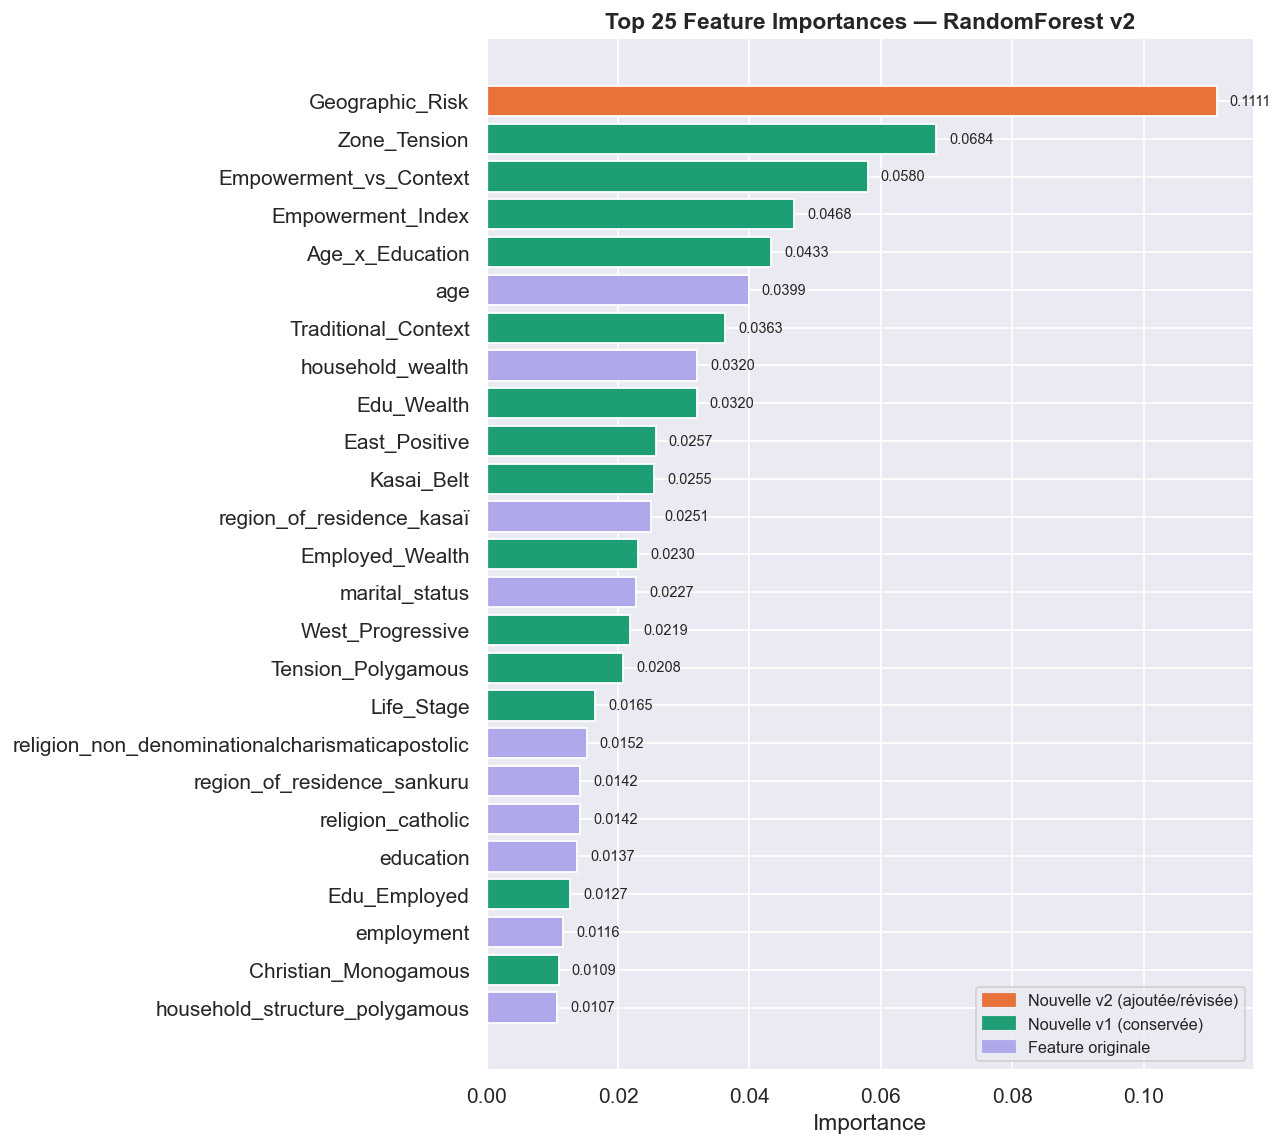


Top 15 features v2 :
  [NEW v2]  Geographic_Risk                                  0.1111
  [NEW v1]  Zone_Tension                                     0.0684
  [NEW v1]  Empowerment_vs_Context                           0.0580
  [NEW v1]  Empowerment_Index                                0.0468
  [NEW v1]  Age_x_Education                                  0.0433
  [ORIG]    age                                              0.0399
  [NEW v1]  Traditional_Context                              0.0363
  [ORIG]    household_wealth                                 0.0320
  [NEW v1]  Edu_Wealth                                       0.0320
  [NEW v1]  East_Positive                                    0.0257
  [NEW v1]  Kasai_Belt                                       0.0255
  [ORIG]    region_of_residence_kasaï                        0.0251
  [NEW v1]  Employed_Wealth                                  0.0230
  [ORIG]    marital_status                                   0.0227
  [NEW v1]  West_Progressi

In [14]:
# ── Feature Importance avec annotation new/original ───────────────────────────
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(
        best_model.feature_importances_,
        index=X_fe.columns
    ).sort_values(ascending=False)

    top_fi    = fi.head(25)
    is_new_fi = ['NEW'  if c in new_features else 'Original' for c in top_fi.index]
    # Parmi les nouvelles, identifier les v2 spécifiques
    v2_only   = added_v2 + revised_v2
    colors_fi = [
        '#E8733A' if c in v2_only   else
        C_NEW     if c in new_features else
        '#AFA9EC'
        for c in top_fi.index
    ]

    fig, ax = plt.subplots(figsize=(10, 9))
    ax.barh(top_fi.index[::-1], top_fi.values[::-1], color=colors_fi[::-1])
    ax.set_title(f'Top 25 Feature Importances — {best_res["name"]} v2',
                 fontweight='bold')
    ax.set_xlabel('Importance')

    legend_handles = [
        mpatches.Patch(color='#E8733A', label='Nouvelle v2 (ajoutée/révisée)'),
        mpatches.Patch(color=C_NEW,    label='Nouvelle v1 (conservée)'),
        mpatches.Patch(color='#AFA9EC', label='Feature originale'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

    for bar, (feat, imp) in zip(ax.patches, reversed(list(top_fi.items()))):
        ax.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('02_feature_importance_v2.png', bbox_inches='tight')
    plt.show()

    print('\nTop 15 features v2 :')
    for feat, imp in fi.head(15).items():
        if feat in v2_only:          tag = '[NEW v2]'
        elif feat in new_features:   tag = '[NEW v1]'
        else:                        tag = '[ORIG]  '
        print(f'  {tag}  {feat:<48} {imp:.4f}')

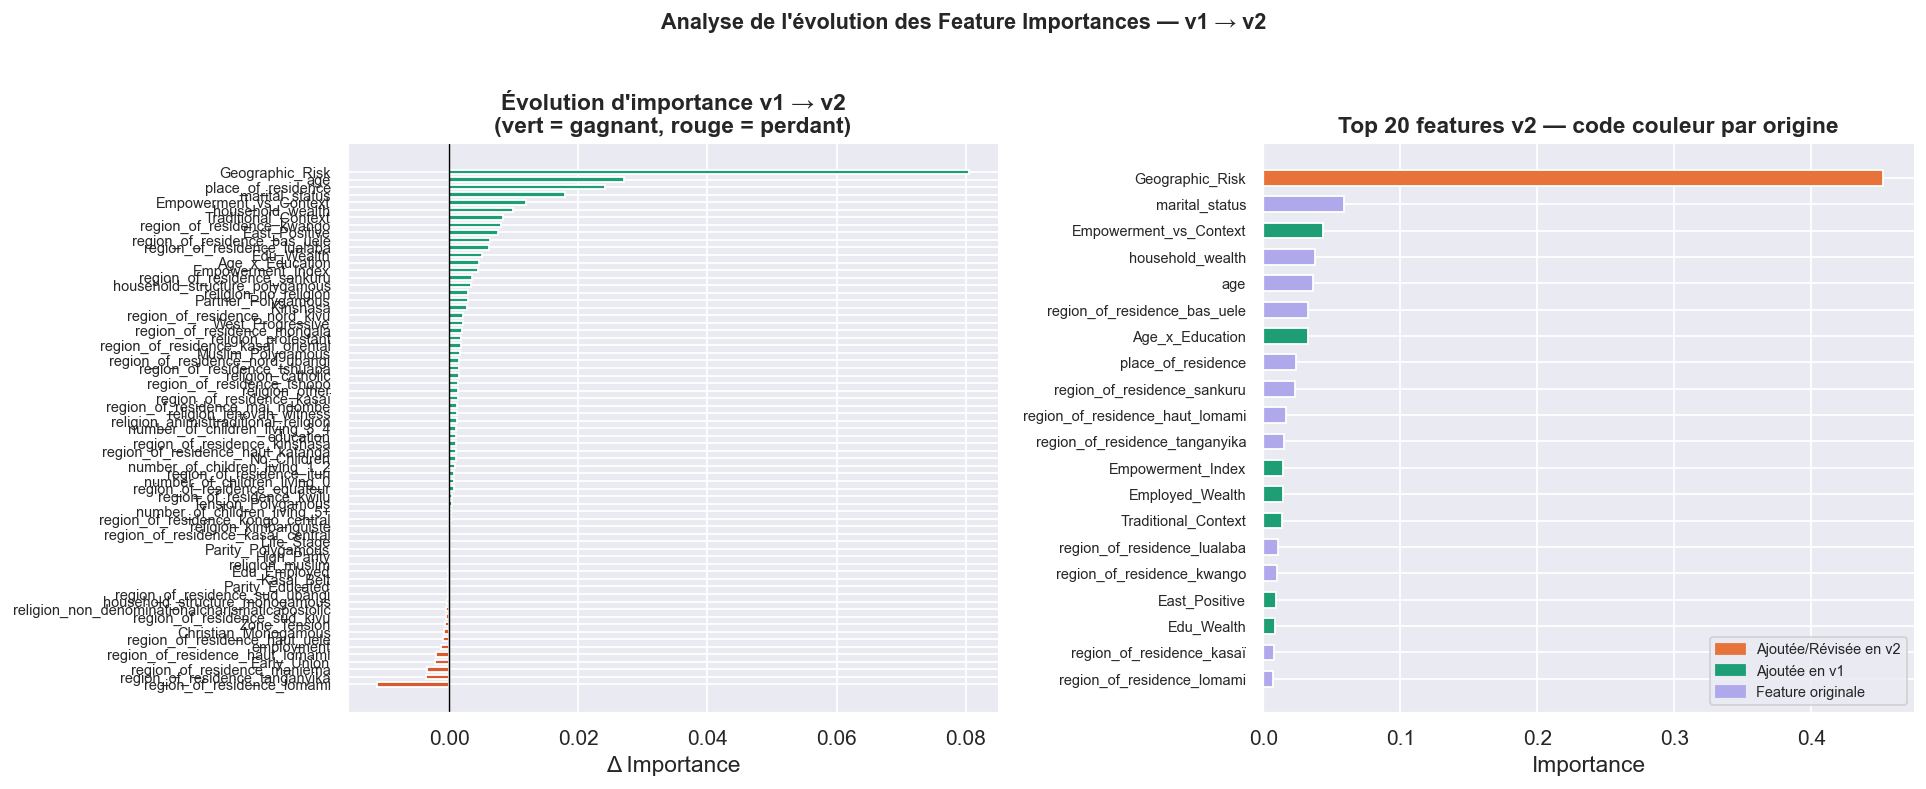

In [15]:
# ── Comparaison des importances v1 vs v2 ─────────────────────────────────────
# Top features qui ont progressé ou regressé

# Reconstruire le modèle v1 pour comparaison
def engineer_features_v1(df):
    """Version v1 du FE (avec les features problématiques maintenant identifiées)."""
    df = df.copy()
    df['Muslim_Polygamous']   = df['religion_muslim'] * df['household_structure_polygamous']
    df['Edu_Employed']        = df['education'] * df['employment']
    df['Edu_Wealth']          = df['education'] * df['household_wealth']
    christian = (df['religion_catholic'] + df['religion_protestant'] +
                 df['religion_non_denominationalcharismaticapostolic']).clip(0,1)
    df['Christian_Monogamous'] = christian * df['household_structure_monogamous']
    df['Urban_Educated']      = df['place_of_residence'] * (df['education'] >= 2).astype(int)
    df['Partner_Polygamous']  = df['marital_status'] * df['household_structure_polygamous']
    df['Zone_Tension']        = (df['region_of_residence_sankuru'] + df['region_of_residence_maniema'] +
                                  df['region_of_residence_nord_ubangi'] + df['region_of_residence_sud_ubangi']).clip(0,1)
    df['Kasai_Belt']          = (df['region_of_residence_kasaï'] + df['region_of_residence_kasaï_central'] +
                                  df['region_of_residence_kasaï_oriental'] + df['region_of_residence_lomami']).clip(0,1)
    df['East_Positive']       = (df['region_of_residence_ituri'] + df['region_of_residence_sud_kivu'] +
                                  df['region_of_residence_nord_kivu']).clip(0,1)
    df['West_Progressive']    = (df['region_of_residence_equateur'] + df['region_of_residence_kwilu'] +
                                  df['region_of_residence_kongo_central'] + df['region_of_residence_mai_ndombe']).clip(0,1)
    df['Kinshasa']            = df['region_of_residence_kinshasa']
    df['Tension_Polygamous']  = df['Zone_Tension'] * df['household_structure_polygamous']
    df['Geographic_Risk']     = df['Zone_Tension']*2 + df['Kasai_Belt']*1 - df['East_Positive']*0.5 - df['West_Progressive']*0.5
    df['No_Children']         = (1 - df['number_of_children_living_1_2'] -
                                  df['number_of_children_living_3_4'] -
                                  df['number_of_children_living_5+']).clip(0,1)
    df['High_Parity']         = df['number_of_children_living_5+']
    df['Parity_Polygamous']   = df['number_of_children_living_5+'] * df['household_structure_polygamous']
    df['Parity_Educated']     = df['number_of_children_living_5+'] * (df['education'] >= 2).astype(int)
    df['Parity_Poor']         = df['number_of_children_living_5+'] * (df['household_wealth'] < df['household_wealth'].median()).astype(int)
    df['Family_Burden']       = df['number_of_children_living_1_2']*1 + df['number_of_children_living_3_4']*2 + df['number_of_children_living_5+']*3 + df['household_structure_polygamous']*2
    age_stage_map             = {0:0,1:0,2:1,3:1,4:1,5:2,6:2}
    df['Life_Stage']          = df['age'].map(age_stage_map)
    df['Age_squared']         = df['age'] ** 2
    df['Age_x_Education']     = df['age'] * df['education']
    df['Early_Union']         = (df['age'] == 0).astype(int)
    df['Senior_Educated']     = ((df['age'] >= 5).astype(int) * (df['education'] >= 2).astype(int))
    s = MinMaxScaler()
    e_n = s.fit_transform(df[['education']]).flatten()
    w_n = s.fit_transform(df[['household_wealth']]).flatten()
    df['Empowerment_Index']       = e_n*0.40 + df['employment']*0.35 + w_n*0.25
    df['Traditional_Context']     = df['religion_muslim']*2 + df['household_structure_polygamous']*1.5 + (1-df['place_of_residence'])*1.0 + (3-df['education'])/3.0 + df['number_of_children_living_5+']*1.0
    df['Empowerment_vs_Context']  = df['Empowerment_Index'] / (df['Traditional_Context'] + 1)
    df['Geographic_Risk']         = df['Zone_Tension']*2 + df['Kasai_Belt']*1 - df['East_Positive']*0.5 - df['West_Progressive']*0.5
    return df

df_v1  = engineer_features_v1(df_raw)
X_v1   = df_v1.drop('Women autonomy', axis=1)
sc_v1  = MinMaxScaler()
X_v1_sc = sc_v1.fit_transform(X_v1)

gb_v1 = GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                    learning_rate=0.1, random_state=RANDOM_STATE)
gb_v1.fit(X_v1_sc, y)
fi_v1 = pd.Series(gb_v1.feature_importances_, index=X_v1.columns)

gb_v2 = GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                    learning_rate=0.1, random_state=RANDOM_STATE)
X_v2_sc = MinMaxScaler().fit_transform(X_fe)
gb_v2.fit(X_v2_sc, y)
fi_v2 = pd.Series(gb_v2.feature_importances_, index=X_fe.columns)

# Features communes — évolution d'importance
common = list(set(fi_v1.index) & set(fi_v2.index))
delta_fi = (fi_v2[common] - fi_v1[common]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Evolution v1→v2
colors_delta = [C_NEW if d > 0 else C_NEG for d in delta_fi.values]
axes[0].barh(delta_fi.index, delta_fi.values, color=colors_delta, height=0.6)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Évolution d\'importance v1 → v2\n(vert = gagnant, rouge = perdant)',
                  fontweight='bold')
axes[0].set_xlabel('Δ Importance')
axes[0].tick_params(axis='y', labelsize=8)

# Top 20 v2 avec code couleur
top20_v2  = fi_v2.sort_values(ascending=True).tail(20)
c20 = ['#E8733A' if c in v2_only else C_NEW if c in new_features else '#AFA9EC'
       for c in top20_v2.index]
axes[1].barh(top20_v2.index, top20_v2.values, color=c20, height=0.6)
axes[1].set_title('Top 20 features v2 — code couleur par origine',
                  fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].tick_params(axis='y', labelsize=8)

legend_handles = [
    mpatches.Patch(color='#E8733A', label='Ajoutée/Révisée en v2'),
    mpatches.Patch(color=C_NEW,    label='Ajoutée en v1'),
    mpatches.Patch(color='#AFA9EC', label='Feature originale'),
]
axes[1].legend(handles=legend_handles, loc='lower right', fontsize=8)

plt.suptitle('Analyse de l\'évolution des Feature Importances — v1 → v2',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('03_importance_evolution.png', bbox_inches='tight')
plt.show()

In [16]:
# ── Analyse SHAP ─────────────────────────────────────────────────────────────
try:
    import shap

    idx_sample = np.random.choice(len(X_test_fe_sc), size=500, replace=False)
    X_shap     = X_test_fe_sc[idx_sample]

    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_shap, feature_names=list(X_fe.columns),
                      max_display=20, show=False, plot_type='bar')
    axes[0].set_title('Importance SHAP moyenne |valeur|', fontweight='bold')

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_shap, feature_names=list(X_fe.columns),
                      max_display=20, show=False)
    axes[1].set_title('Impact SHAP : direction + magnitude', fontweight='bold')

    plt.suptitle('Analyse SHAP — Feature Engineering v2', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('04_shap_v2.png', bbox_inches='tight')
    plt.show()

except ImportError:
    print('SHAP non installé : pip install shap')

SHAP non installé : pip install shap


---
## 7. Matrice de Confusion & Courbes ROC

=== Classification Report — RandomForest FE v2 ===
                  precision    recall  f1-score   support

Pas autonome (0)       0.73      0.51      0.60      1940
    Autonome (1)       0.53      0.75      0.62      1448

        accuracy                           0.61      3388
       macro avg       0.63      0.63      0.61      3388
    weighted avg       0.65      0.61      0.61      3388



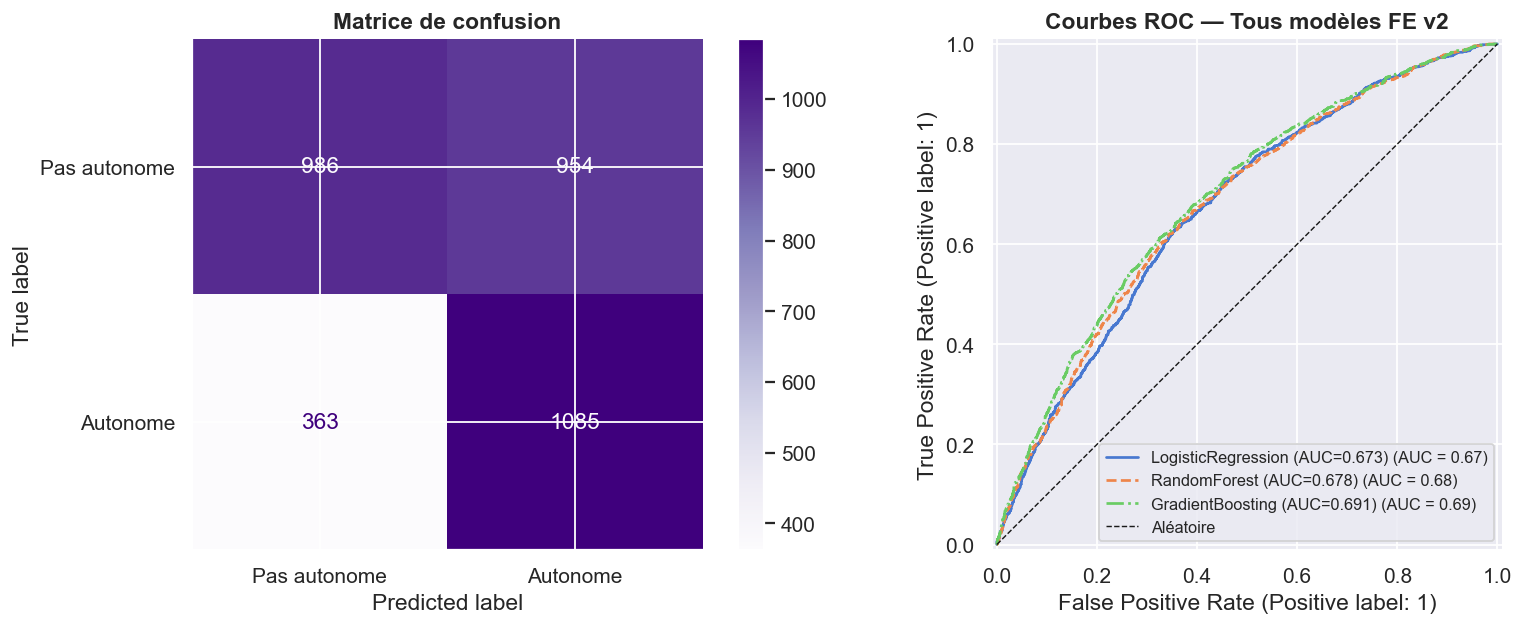

In [17]:
y_pred_best = best_model.predict(X_test_fe_sc)
print(f'=== Classification Report — {best_res["name"]} FE v2 ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Pas autonome (0)', 'Autonome (1)']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_fe_sc, y_test,
    display_labels=['Pas autonome','Autonome'],
    cmap='Purples', ax=axes[0]
)
axes[0].set_title(f'Matrice de confusion', fontweight='bold')

for res, ls in zip(fe_results, ['-', '--', '-.']):
    if res['test_auc'] is not None:
        RocCurveDisplay.from_estimator(
            res['fitted_model'], X_test_fe_sc, y_test,
            name=f"{res['name']} (AUC={res['test_auc']:.3f})",
            ax=axes[1], linestyle=ls
        )
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Aléatoire')
axes[1].set_title('Courbes ROC — Tous modèles FE v2', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_confusion_roc_v2.png', bbox_inches='tight')
plt.show()

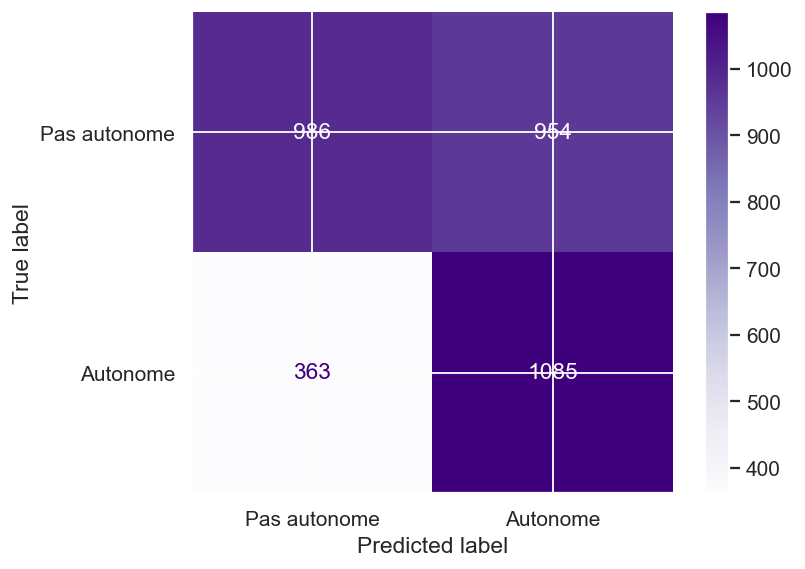

In [18]:
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_fe_sc, y_test,
    display_labels=['Pas autonome','Autonome'],
    cmap='Purples'
)

---
## 8. Optimisation Hyperparamètres

In [ ]:
pipe_final = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf',    GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    'clf__n_estimators'    : [150, 300, 500],
    'clf__max_depth'       : [3, 4, 5],
    'clf__learning_rate'   : [0.03, 0.05, 0.1],
    'clf__subsample'       : [0.7, 0.8, 1.0],
    'clf__min_samples_leaf': [5, 10, 20]
}

# CV respectant les grappes géographiques si PSU disponible
if psu_clusters is not None:
    from sklearn.model_selection import StratifiedGroupKFold
    cv_gs = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    psu_train_fe_gs = psu_clusters[X_train_fe.index]
    fit_params_gs   = {'clf__sample_weight': w_train_fe} if w_train_fe is not None else {}
    grid_search = GridSearchCV(
        pipe_final, param_grid,
        cv=cv_gs, scoring='roc_auc',
        n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train_fe, y_train,
                    groups=psu_train_fe_gs,
                    **fit_params_gs)
    print('✅ GridSearch avec StratifiedGroupKFold (PSU) et sample_weight')
else:
    cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    grid_search = GridSearchCV(
        pipe_final, param_grid,
        cv=cv_gs, scoring='roc_auc',
        n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train_fe, y_train)
    print('⚠️  GridSearch sans pondération (Survey_Weight absent)')

print(f'Meilleurs paramètres : {grid_search.best_params_}')
print(f'Meilleur AUC CV      : {grid_search.best_score_:.4f}')


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


In [ ]:
best_pipe   = grid_search.best_estimator_
y_pred_fin  = best_pipe.predict(X_test_fe)
y_proba_fin = best_pipe.predict_proba(X_test_fe)[:,1]

final_auc = roc_auc_score(y_test, y_proba_fin)
final_acc = accuracy_score(y_test, y_pred_fin)
final_f1  = f1_score(y_test, y_pred_fin)

print('=== MODÈLE FINAL ===')
print(f'AUC : {final_auc:.4f} | Accuracy : {final_acc:.4f} | F1 : {final_f1:.4f}')
print()
print(classification_report(y_test, y_pred_fin,
                             target_names=['Pas autonome','Autonome']))

=== MODÈLE FINAL ===
AUC : 0.6857 | Accuracy : 0.6464 | F1 : 0.5817

              precision    recall  f1-score   support

Pas autonome       0.69      0.70      0.69      1940
    Autonome       0.59      0.58      0.58      1448

    accuracy                           0.65      3388
   macro avg       0.64      0.64      0.64      3388
weighted avg       0.65      0.65      0.65      3388



Étape,Modèle,AUC CV,AUC Test,F1 Test,Features
1. Baseline,GradientBoosting,0.6848,0.6904,0.5753,50
2. + FE v1 (intuitif),GradientBoosting,0.6847,—,—,64
3. + FE v2 (guidé EDA),RandomForest,0.6812,0.6783,0.6223,76
4. + Optimisation,GradientBoosting (tuné),0.6850,0.6857,0.5817,76


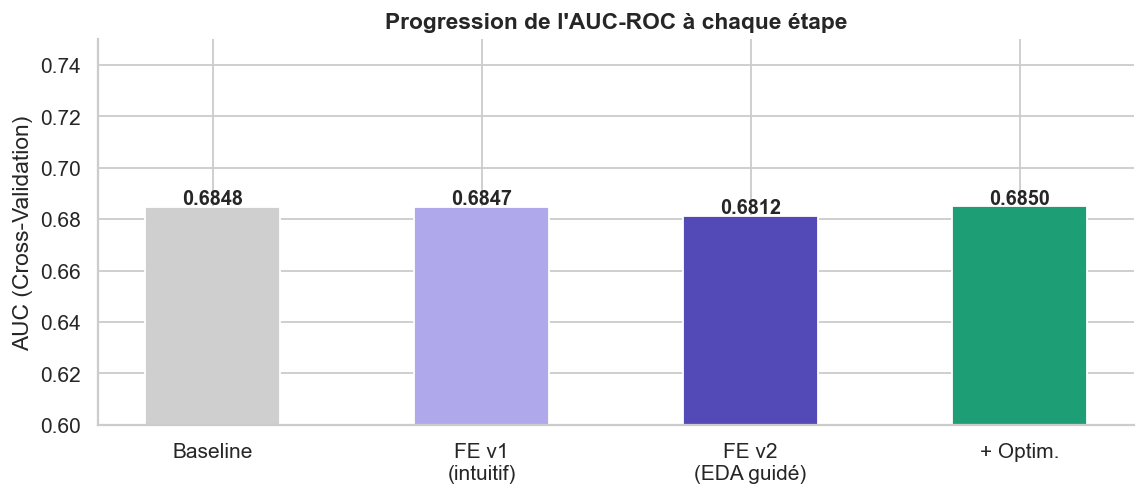

In [ ]:
# ── Bilan global : Baseline → FE v1 → FE v2 → Optimisé ──────────────────────
best_b   = max(baseline_results, key=lambda r: r['cv_auc_mean'])
best_fev1_auc = max(fe_v1_ref[m]['cv_auc_mean'] for m in fe_v1_ref)
best_fev1_name = max(fe_v1_ref, key=lambda m: fe_v1_ref[m]['cv_auc_mean'])

summary = pd.DataFrame([
    {'Étape': '1. Baseline',
     'Modèle': best_b['name'],
     'AUC CV': best_b['cv_auc_mean'],
     'AUC Test': best_b['test_auc'],
     'F1 Test': best_b['test_f1'],
     'Features': df_raw.shape[1]-1},
    {'Étape': '2. + FE v1 (intuitif)',
     'Modèle': best_fev1_name,
     'AUC CV': best_fev1_auc,
     'AUC Test': None,
     'F1 Test': None,
     'Features': 64},
    {'Étape': '3. + FE v2 (guidé EDA)',
     'Modèle': best_res['name'],
     'AUC CV': best_res['cv_auc_mean'],
     'AUC Test': best_res['test_auc'],
     'F1 Test': best_res['test_f1'],
     'Features': X_fe.shape[1]},
    {'Étape': '4. + Optimisation',
     'Modèle': 'GradientBoosting (tuné)',
     'AUC CV': grid_search.best_score_,
     'AUC Test': final_auc,
     'F1 Test': final_f1,
     'Features': X_fe.shape[1]},
])

display(
    summary.style
    .format({'AUC CV':'{:.4f}','AUC Test':'{:.4f}','F1 Test':'{:.4f}','Features':'{:.0f}'},
            na_rep='—')
    .set_caption('Progression complète — Baseline → FE v1 → FE v2 (EDA guidé) → Optimisé')
    .background_gradient(subset=['AUC CV'], cmap='Purples', axis=0)
    .hide(axis="index")
)

# Graphe de progression
steps    = ['Baseline', 'FE v1\n(intuitif)', 'FE v2\n(EDA guidé)', '+ Optim.']
auc_cv   = [best_b['cv_auc_mean'], best_fev1_auc,
             best_res['cv_auc_mean'], grid_search.best_score_]

fig, ax = plt.subplots(figsize=(9, 4))
colors_prog = ['#CFCFCF', '#AFA9EC', C_POS, '#1D9E75']
bars_p = ax.bar(steps, auc_cv, color=colors_prog, edgecolor='white', width=0.5)
ax.set_ylim(0.60, 0.75)
ax.set_title('Progression de l\'AUC-ROC à chaque étape', fontweight='bold')
ax.set_ylabel('AUC (Cross-Validation)')
for bar, v in zip(bars_p, auc_cv):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001,
            f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('06_progression_auc.png', bbox_inches='tight')
plt.show()

---
## 9. Sauvegarde

In [ ]:
import joblib

# Sauvegarder le modèle + le scaler + les métadonnées de conception
model_metadata = {
    'model'              : best_pipe,
    'feature_names'      : list(X_fe.columns),
    'design_info'        : {
        'weighted'       : survey_weights is not None,
        'group_kfold'    : psu_clusters is not None,
        'n_psu_clusters' : int(df_raw['PSU_Cluster'].nunique()) if 'PSU_Cluster' in df_raw.columns else None,
        'n_strata'       : int(df_raw['Survey_Strata'].nunique()) if 'Survey_Strata' in df_raw.columns else None,
    },
    'global_rate'        : float(GLOBAL_RATE),
}

joblib.dump(model_metadata, 'model_final_congo_v2.pkl')
print('✅ Modèle sauvegardé : model_final_congo_v2.pkl')
print(f'   Pondéré           : {model_metadata["design_info"]["weighted"]}')
print(f'   GroupKFold PSU    : {model_metadata["design_info"]["group_kfold"]}')
print(f'   Grappes           : {model_metadata["design_info"]["n_psu_clusters"]}')
print(f'   Strates           : {model_metadata["design_info"]["n_strata"]}')

sample      = X_test_fe.iloc[[0]].copy()
pred        = best_pipe.predict(sample)[0]
proba       = best_pipe.predict_proba(sample)[0]
print(f'\nExemple prédiction : {"Autonome" if pred==1 else "Pas autonome"} '
      f'(P={proba[pred]:.3f}) | Réel : {y_test.iloc[0]}')

print('''
── Réutilisation sur nouvelles données ──────────────────────────
import joblib
bundle = joblib.load('model_final_congo_v2.pkl')
pipe   = bundle['model']

# Appliquer le même preprocessing + FE
df_new    = pd.read_csv('nouvelles_donnees.csv')
# Retirer les colonnes de conception avant FE
DESIGN    = ['Survey_Weight', 'PSU_Cluster', 'Survey_Strata']
df_new_ml = df_new.drop(columns=[c for c in DESIGN if c in df_new.columns])
df_new_fe = engineer_features_v2(df_new_ml)
X_new     = df_new_fe.drop('Women autonomy', axis=1, errors='ignore')
# Vérifier l'ordre des colonnes
X_new     = X_new[bundle['feature_names']]
preds     = pipe.predict(X_new)
probas    = pipe.predict_proba(X_new)[:,1]
''')


✅ Modèle sauvegardé : model_final_congo_v2.pkl
   Pondéré           : True
   GroupKFold PSU    : True
   Grappes           : 778
   Strates           : 51

Exemple prédiction : Autonome (P=0.627) | Réel : 0

── Réutilisation sur nouvelles données ──────────────────────────
import joblib
bundle = joblib.load('model_final_congo_v2.pkl')
pipe   = bundle['model']

# Appliquer le même preprocessing + FE
df_new    = pd.read_csv('nouvelles_donnees.csv')
# Retirer les colonnes de conception avant FE
DESIGN    = ['Survey_Weight', 'PSU_Cluster', 'Survey_Strata']
df_new_ml = df_new.drop(columns=[c for c in DESIGN if c in df_new.columns])
df_new_fe = engineer_features_v2(df_new_ml)
X_new     = df_new_fe.drop('Women autonomy', axis=1, errors='ignore')
# Vérifier l'ordre des colonnes
X_new     = X_new[bundle['feature_names']]
preds     = pipe.predict(X_new)
probas    = pipe.predict_proba(X_new)[:,1]

